# Model Comparison: Logistic Regression vs XGBoost vs Random Forest
Train and compare three model types on both feature sets:
- **7 features** (balanced, low overfitting)
- **23 features** (optimal test accuracy)

**Models:**
1. Logistic Regression (baseline)
2. XGBoost
3. Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Load Data

In [2]:
# Load full dataset
df = pd.read_csv('../data/processed/tournament_matchups.csv')

# Define feature sets
features_7 = [
    'diff_srs', 'diff_pts_for', 'diff_trb', 'diff_sos', 
    'seed_diff', 'diff_pts_against', 'diff_ast'
]

features_23 = [
    'diff_srs', 'diff_pts_for', 'diff_trb', 'diff_sos', 'seed_diff',
    'diff_pts_against', 'diff_ast', 'diff_win_pct', 'diff_three_made',
    'diff_ortg', 'diff_blk', 'diff_stl', 'diff_tov_pct', 'diff_pace',
    'diff_ts_pct', 'diff_tov', 'diff_ft_pct', 'diff_fg_pct', 'diff_efg_pct',
    'diff_three_pct', 'diff_blk_pct', 'diff_ftr', 'diff_trb_pct'
]

print(f'Dataset: {df.shape}')
print(f'7-feature set: {features_7}')
print(f'23-feature set: {len(features_23)} features')

Dataset: (477, 91)
7-feature set: ['diff_srs', 'diff_pts_for', 'diff_trb', 'diff_sos', 'seed_diff', 'diff_pts_against', 'diff_ast']
23-feature set: 23 features


In [3]:
# Train/test split (temporal)
train_mask = df['season'] <= 2022
test_mask = df['season'] >= 2023

# 7 features
X_train_7 = df.loc[train_mask, features_7].values
X_test_7 = df.loc[test_mask, features_7].values

# 23 features
X_train_23 = df.loc[train_mask, features_23].values
X_test_23 = df.loc[test_mask, features_23].values

# Target
y_train = df.loc[train_mask, 'home_win'].values
y_test = df.loc[test_mask, 'home_win'].values

print(f'Training: {len(y_train)} games')
print(f'Test: {len(y_test)} games')

Training: 388 games
Test: 89 games


In [4]:
# Scale features (needed for Logistic Regression)
scaler_7 = StandardScaler()
scaler_23 = StandardScaler()

X_train_7_scaled = scaler_7.fit_transform(X_train_7)
X_test_7_scaled = scaler_7.transform(X_test_7)

X_train_23_scaled = scaler_23.fit_transform(X_train_23)
X_test_23_scaled = scaler_23.transform(X_test_23)

print('Features scaled')

Features scaled


## 2. Define Models

In [5]:
# Model definitions
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Logistic Regression
  - Random Forest
  - XGBoost


## 3. Train and Evaluate All Models

In [6]:
def evaluate_model(model, X_train, X_test, y_train, y_test, use_scaled=True):
    """Train and evaluate a model, return metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    return {
        'train_acc': accuracy_score(y_train, y_pred_train),
        'cv_acc': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test),
        'recall': recall_score(y_test, y_pred_test),
        'f1': f1_score(y_test, y_pred_test),
        'roc_auc': roc_auc_score(y_test, y_prob_test),
        'overfit_gap': accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test),
        'y_pred': y_pred_test,
        'y_prob': y_prob_test,
        'model': model
    }

In [7]:
# Train all models on both feature sets
results = {}

print('Training models...')
print('='*70)

for model_name, model_template in models.items():
    for n_features, (X_tr, X_te, X_tr_sc, X_te_sc) in [
        (7, (X_train_7, X_test_7, X_train_7_scaled, X_test_7_scaled)),
        (23, (X_train_23, X_test_23, X_train_23_scaled, X_test_23_scaled))
    ]:
        # Clone model for fresh training
        from sklearn.base import clone
        model = clone(model_template)
        
        # Use scaled data for Logistic Regression, raw for tree-based
        if model_name == 'Logistic Regression':
            metrics = evaluate_model(model, X_tr_sc, X_te_sc, y_train, y_test)
        else:
            metrics = evaluate_model(model, X_tr, X_te, y_train, y_test)
        
        key = f'{model_name} ({n_features}f)'
        results[key] = metrics
        
        print(f'{key:35s} | Test: {metrics["test_acc"]:.1%} | AUC: {metrics["roc_auc"]:.3f} | Gap: {metrics["overfit_gap"]:.1%}')

print('='*70)

Training models...
Logistic Regression (7f)            | Test: 76.4% | AUC: 0.802 | Gap: 1.9%
Logistic Regression (23f)           | Test: 77.5% | AUC: 0.861 | Gap: 7.3%


Random Forest (7f)                  | Test: 73.0% | AUC: 0.775 | Gap: 22.6%


Random Forest (23f)                 | Test: 69.7% | AUC: 0.790 | Gap: 29.3%


XGBoost (7f)                        | Test: 71.9% | AUC: 0.753 | Gap: 28.1%


XGBoost (23f)                       | Test: 73.0% | AUC: 0.798 | Gap: 27.0%


## 4. Results Comparison

In [8]:
# Create comparison dataframe
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Train Acc': metrics['train_acc'],
        'CV Acc': metrics['cv_acc'],
        'Test Acc': metrics['test_acc'],
        'ROC-AUC': metrics['roc_auc'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1': metrics['f1'],
        'Overfit Gap': metrics['overfit_gap']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test Acc', ascending=False)

print('Model Comparison (sorted by Test Accuracy):')
print('='*100)
print(comparison_df.to_string(index=False))

Model Comparison (sorted by Test Accuracy):
                    Model  Train Acc   CV Acc  Test Acc  ROC-AUC  Precision   Recall       F1  Overfit Gap
Logistic Regression (23f)   0.847938 0.840160  0.775281 0.861294   0.824561 0.824561 0.824561     0.072657
 Logistic Regression (7f)   0.783505 0.770829  0.764045 0.802083   0.781250 0.877193 0.826446     0.019460
       Random Forest (7f)   0.956186 0.770829  0.730337 0.774671   0.770492 0.824561 0.796610     0.225848
            XGBoost (23f)   1.000000 0.775791  0.730337 0.797697   0.753846 0.859649 0.803279     0.269663
             XGBoost (7f)   1.000000 0.732001  0.719101 0.752741   0.758065 0.824561 0.789916     0.280899
      Random Forest (23f)   0.989691 0.781119  0.696629 0.790022   0.734375 0.824561 0.776860     0.293062


In [9]:
# Styled comparison
styled_df = comparison_df.copy()
styled_df['Train Acc'] = styled_df['Train Acc'].apply(lambda x: f'{x:.1%}')
styled_df['CV Acc'] = styled_df['CV Acc'].apply(lambda x: f'{x:.1%}')
styled_df['Test Acc'] = styled_df['Test Acc'].apply(lambda x: f'{x:.1%}')
styled_df['ROC-AUC'] = styled_df['ROC-AUC'].apply(lambda x: f'{x:.3f}')
styled_df['Precision'] = styled_df['Precision'].apply(lambda x: f'{x:.1%}')
styled_df['Recall'] = styled_df['Recall'].apply(lambda x: f'{x:.1%}')
styled_df['F1'] = styled_df['F1'].apply(lambda x: f'{x:.3f}')
styled_df['Overfit Gap'] = styled_df['Overfit Gap'].apply(lambda x: f'{x:.1%}')

styled_df

,Model,Train Acc,CV Acc,Test Acc,ROC-AUC,Precision,Recall,F1,Overfit Gap
1,Logistic Regression (23f),84.8%,84.0%,77.5%,0.861,82.5%,82.5%,0.825,7.3%
0,Logistic Regression (7f),78.4%,77.1%,76.4%,0.802,78.1%,87.7%,0.826,1.9%
2,Random Forest (7f),95.6%,77.1%,73.0%,0.775,77.0%,82.5%,0.797,22.6%
5,XGBoost (23f),100.0%,77.6%,73.0%,0.798,75.4%,86.0%,0.803,27.0%
4,XGBoost (7f),100.0%,73.2%,71.9%,0.753,75.8%,82.5%,0.790,28.1%
3,Random Forest (23f),99.0%,78.1%,69.7%,0.790,73.4%,82.5%,0.777,29.3%


## 5. Visualizations

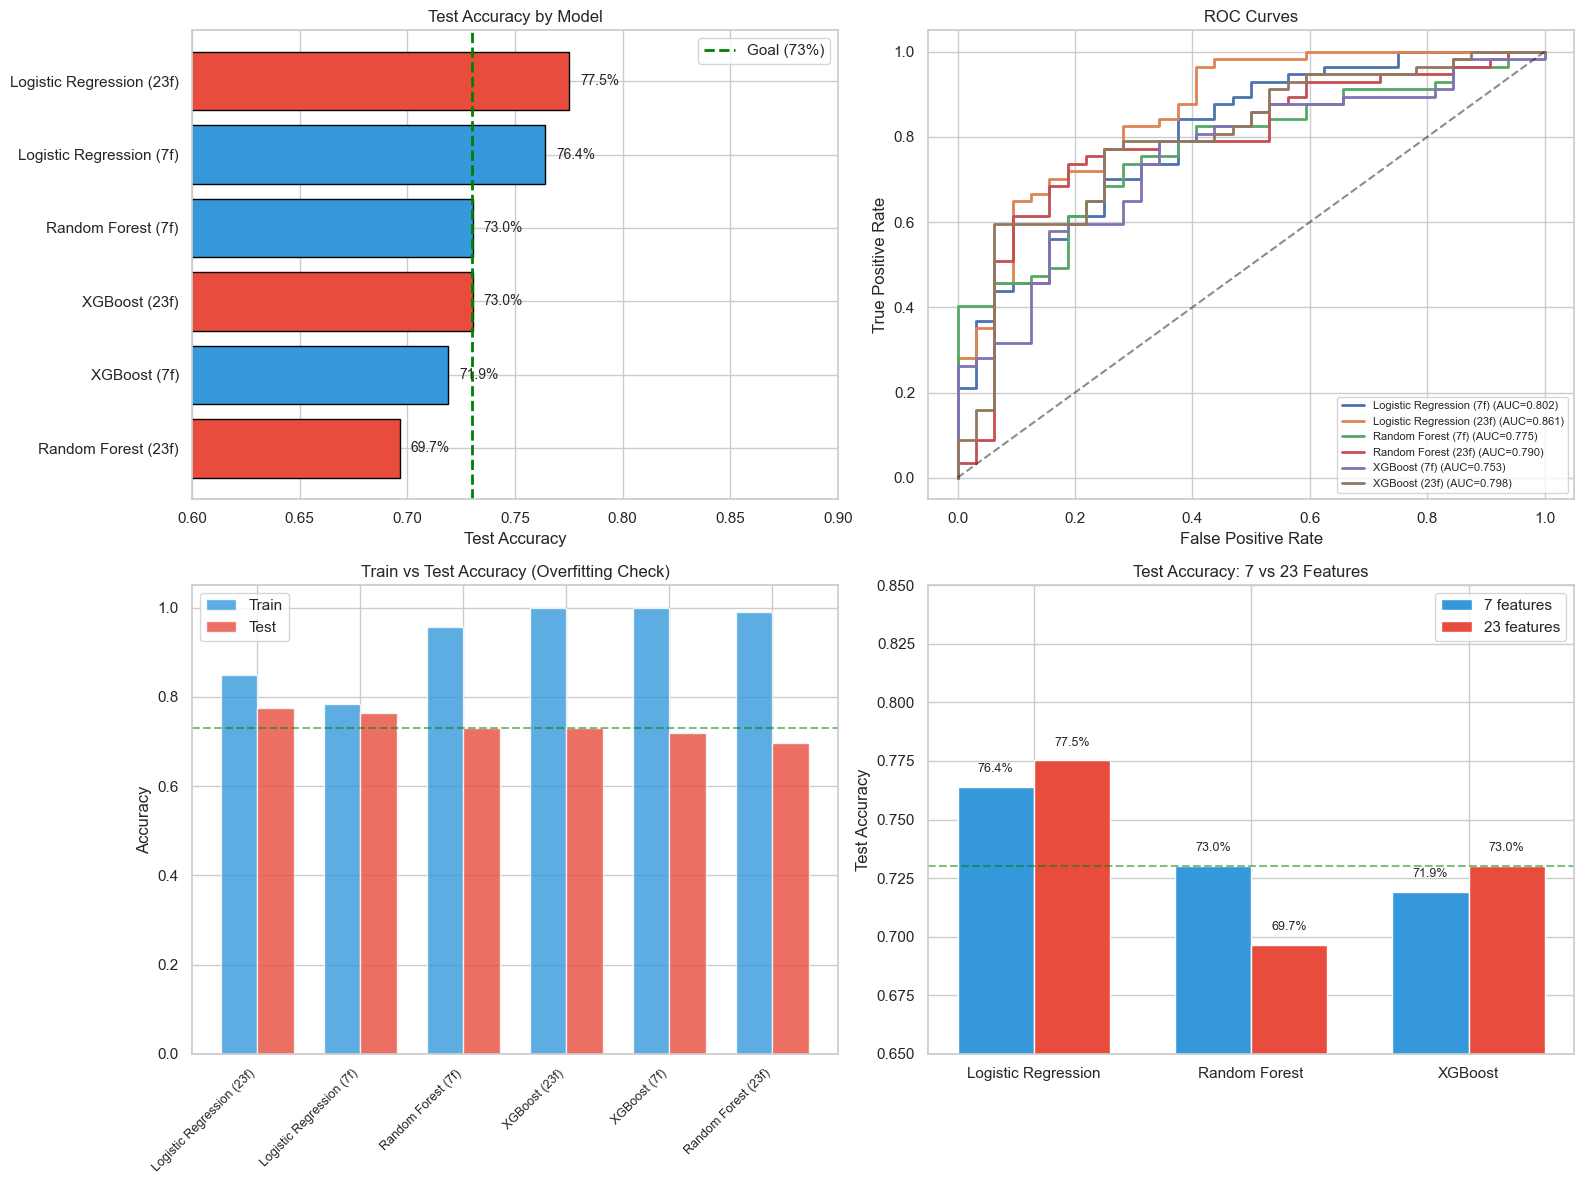

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test Accuracy comparison
ax = axes[0, 0]
models_sorted = comparison_df.sort_values('Test Acc', ascending=True)
colors = ['#3498db' if '7f' in m else '#e74c3c' for m in models_sorted['Model']]
bars = ax.barh(models_sorted['Model'], models_sorted['Test Acc'], color=colors, edgecolor='black')
ax.axvline(x=0.73, color='green', linestyle='--', linewidth=2, label='Goal (73%)')
ax.set_xlabel('Test Accuracy')
ax.set_title('Test Accuracy by Model')
ax.legend()
for bar, val in zip(bars, models_sorted['Test Acc']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=10)
ax.set_xlim(0.6, 0.9)

# Plot 2: ROC Curves
ax = axes[0, 1]
for name, metrics in results.items():
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={metrics["roc_auc"]:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=8)

# Plot 3: Overfitting comparison
ax = axes[1, 0]
x = range(len(comparison_df))
width = 0.35
ax.bar([i - width/2 for i in x], comparison_df['Train Acc'], width, label='Train', color='#3498db', alpha=0.8)
ax.bar([i + width/2 for i in x], comparison_df['Test Acc'], width, label='Test', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy (Overfitting Check)')
ax.legend()
ax.axhline(y=0.73, color='green', linestyle='--', alpha=0.5)

# Plot 4: Feature count comparison by model type
ax = axes[1, 1]
model_types = ['Logistic Regression', 'Random Forest', 'XGBoost']
x = np.arange(len(model_types))
width = 0.35

acc_7 = [results[f'{m} (7f)']['test_acc'] for m in model_types]
acc_23 = [results[f'{m} (23f)']['test_acc'] for m in model_types]

bars1 = ax.bar(x - width/2, acc_7, width, label='7 features', color='#3498db')
bars2 = ax.bar(x + width/2, acc_23, width, label='23 features', color='#e74c3c')

ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy: 7 vs 23 Features')
ax.set_xticks(x)
ax.set_xticklabels(model_types)
ax.legend()
ax.axhline(y=0.73, color='green', linestyle='--', alpha=0.5, label='Goal')
ax.set_ylim(0.65, 0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005, f'{height:.1%}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/visualizations/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance (Tree-based models)

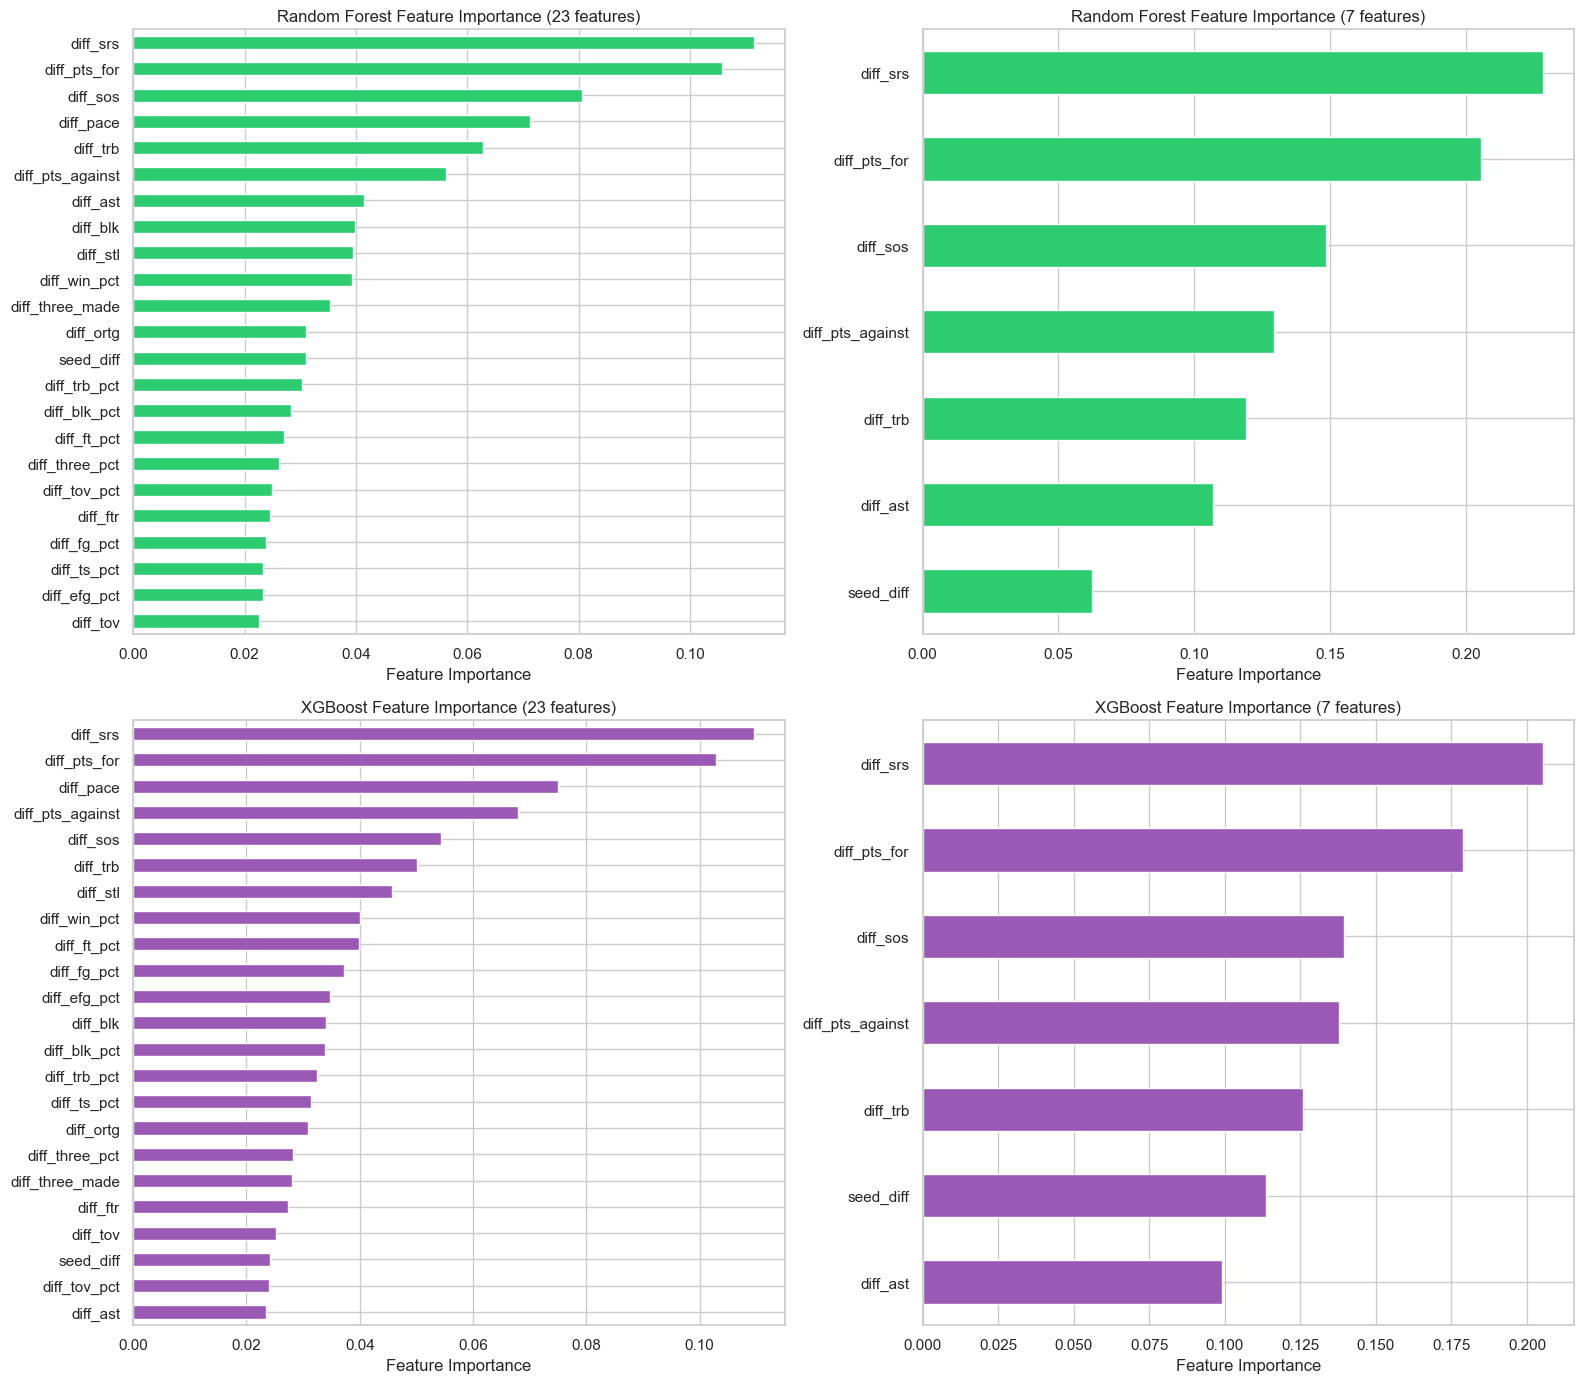

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Random Forest - 23 features
ax = axes[0, 0]
rf_model = results['Random Forest (23f)']['model']
importances = pd.Series(rf_model.feature_importances_, index=features_23).sort_values(ascending=True)
importances.plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance (23 features)')

# Random Forest - 7 features
ax = axes[0, 1]
rf_model_7 = results['Random Forest (7f)']['model']
importances_7 = pd.Series(rf_model_7.feature_importances_, index=features_7).sort_values(ascending=True)
importances_7.plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance (7 features)')

# XGBoost - 23 features
ax = axes[1, 0]
xgb_model = results['XGBoost (23f)']['model']
importances_xgb = pd.Series(xgb_model.feature_importances_, index=features_23).sort_values(ascending=True)
importances_xgb.plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost Feature Importance (23 features)')

# XGBoost - 7 features
ax = axes[1, 1]
xgb_model_7 = results['XGBoost (7f)']['model']
importances_xgb_7 = pd.Series(xgb_model_7.feature_importances_, index=features_7).sort_values(ascending=True)
importances_xgb_7.plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost Feature Importance (7 features)')

plt.tight_layout()
plt.savefig('../results/visualizations/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Upset Analysis

In [12]:
# Analyze upset prediction performance
test_df = df[test_mask].copy()
test_df['upset'] = ((test_df['home_seed'] > test_df['away_seed']) & (test_df['home_win'] == 1)) | \
                   ((test_df['away_seed'] > test_df['home_seed']) & (test_df['home_win'] == 0))

upset_mask = test_df['upset'].values
chalk_mask = ~upset_mask

print('Upset Prediction Analysis')
print('='*70)
print(f'Total test games: {len(y_test)}')
print(f'Upsets: {upset_mask.sum()} ({upset_mask.mean():.1%})')
print(f'Chalk: {chalk_mask.sum()} ({chalk_mask.mean():.1%})')
print()

upset_results = []
for name, metrics in results.items():
    y_pred = metrics['y_pred']
    upset_acc = accuracy_score(y_test[upset_mask], y_pred[upset_mask])
    chalk_acc = accuracy_score(y_test[chalk_mask], y_pred[chalk_mask])
    
    upset_results.append({
        'Model': name,
        'Overall': metrics['test_acc'],
        'Upset Acc': upset_acc,
        'Chalk Acc': chalk_acc
    })
    print(f'{name:35s} | Upset: {upset_acc:.1%} | Chalk: {chalk_acc:.1%}')

upset_df = pd.DataFrame(upset_results).sort_values('Upset Acc', ascending=False)
print()
print('Best at predicting upsets:', upset_df.iloc[0]['Model'])

Upset Prediction Analysis
Total test games: 89
Upsets: 27 (30.3%)
Chalk: 62 (69.7%)

Logistic Regression (7f)            | Upset: 55.6% | Chalk: 85.5%
Logistic Regression (23f)           | Upset: 66.7% | Chalk: 82.3%
Random Forest (7f)                  | Upset: 55.6% | Chalk: 80.6%
Random Forest (23f)                 | Upset: 44.4% | Chalk: 80.6%
XGBoost (7f)                        | Upset: 48.1% | Chalk: 82.3%
XGBoost (23f)                       | Upset: 48.1% | Chalk: 83.9%

Best at predicting upsets: Logistic Regression (23f)


## 8. Save Best Models

In [13]:
# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_metrics = results[best_model_name]

print(f'Best Model: {best_model_name}')
print(f'  Test Accuracy: {best_metrics["test_acc"]:.1%}')
print(f'  ROC-AUC: {best_metrics["roc_auc"]:.3f}')

Best Model: Logistic Regression (23f)
  Test Accuracy: 77.5%
  ROC-AUC: 0.861


In [14]:
# Save all models
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save each model
for name, metrics in results.items():
    # Create clean filename
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('f', 'features')
    joblib.dump(metrics['model'], models_dir / f'{filename}.pkl')

# Save scalers
joblib.dump(scaler_7, models_dir / 'scaler_7features.pkl')
joblib.dump(scaler_23, models_dir / 'scaler_23features.pkl')

# Save feature lists
joblib.dump(features_7, models_dir / 'features_7.pkl')
joblib.dump(features_23, models_dir / 'features_23.pkl')

print('Saved models:')
for f in sorted(models_dir.glob('*.pkl')):
    print(f'  - {f.name}')

Saved models:
  - features_23.pkl
  - features_7.pkl
  - features_a.pkl
  - features_b.pkl
  - logistic_model_a.pkl
  - logistic_model_b.pkl
  - logistic_regression_23features.pkl
  - logistic_regression_7features.pkl
  - random_featuresorest_23features.pkl
  - random_featuresorest_7features.pkl
  - scaler_23features.pkl
  - scaler_7features.pkl
  - scaler_a.pkl
  - scaler_b.pkl
  - xgboost_23features.pkl
  - xgboost_7features.pkl


## 9. Summary

In [15]:
print('='*70)
print('MODEL COMPARISON SUMMARY')
print('='*70)

print('\nRankings by Test Accuracy:')
for i, (_, row) in enumerate(comparison_df.iterrows(), 1):
    print(f"  {i}. {row['Model']:35s} {row['Test Acc']:.1%} (AUC: {row['ROC-AUC']:.3f})")

print('\n' + '-'*70)
print('Key Findings:')
print(f"  - Best overall: {comparison_df.iloc[0]['Model']} ({comparison_df.iloc[0]['Test Acc']:.1%})")

# Best by feature count
best_7f = comparison_df[comparison_df['Model'].str.contains('7f')].iloc[0]
best_23f = comparison_df[comparison_df['Model'].str.contains('23f')].iloc[0]
print(f"  - Best with 7 features: {best_7f['Model']} ({best_7f['Test Acc']:.1%})")
print(f"  - Best with 23 features: {best_23f['Model']} ({best_23f['Test Acc']:.1%})")

# Lowest overfitting
lowest_overfit = comparison_df.loc[comparison_df['Overfit Gap'].idxmin()]
print(f"  - Lowest overfitting: {lowest_overfit['Model']} (gap: {lowest_overfit['Overfit Gap']:.1%})")

print('\n' + '-'*70)
print(f'Goal: >73% accuracy')
above_goal = comparison_df[comparison_df['Test Acc'] > 0.73]
print(f'Models above goal: {len(above_goal)}/{len(comparison_df)}')
print('='*70)

MODEL COMPARISON SUMMARY

Rankings by Test Accuracy:
  1. Logistic Regression (23f)           77.5% (AUC: 0.861)
  2. Logistic Regression (7f)            76.4% (AUC: 0.802)
  3. Random Forest (7f)                  73.0% (AUC: 0.775)
  4. XGBoost (23f)                       73.0% (AUC: 0.798)
  5. XGBoost (7f)                        71.9% (AUC: 0.753)
  6. Random Forest (23f)                 69.7% (AUC: 0.790)

----------------------------------------------------------------------
Key Findings:
  - Best overall: Logistic Regression (23f) (77.5%)
  - Best with 7 features: Logistic Regression (7f) (76.4%)
  - Best with 23 features: Logistic Regression (23f) (77.5%)
  - Lowest overfitting: Logistic Regression (7f) (gap: 1.9%)

----------------------------------------------------------------------
Goal: >73% accuracy
Models above goal: 4/6
